<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Spam_vs_Ham_Email_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1: Data Loading dan Eksplorasi

##  Import Library dan Download Dataset

In [1]:
import pandas as pd
import requests
import zipfile
import io

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

# Download the ZIP file content
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

# The desired file name inside the zip
csv_file_name = 'SMSSpamCollection'

# Read the specific file from the zip archive
with zip_file.open(csv_file_name) as f:
    df = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Melihat Bentuk dan Info Data

In [2]:
print("Shape:", df.shape)

print("\nInfo:")
df.info()

Shape: (5572, 2)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


## Memeriksa Data Kosong dan Duplikat

In [3]:
print("Nilai kosong per kolom:")
print(df.isnull().sum())

print(f"\nJumlah data duplikat: {df.duplicated().sum()}")

df = df.drop_duplicates()
print(f"Shape setelah hapus duplikat: {df.shape}")

Nilai kosong per kolom:
label      0
message    0
dtype: int64

Jumlah data duplikat: 403
Shape setelah hapus duplikat: (5169, 2)


## Melihat Distribusi Label

In [4]:
print("Distribusi label:")
print(df['label'].value_counts())

print("\nPersentase:")
print(df['label'].value_counts(normalize=True).round(4) * 100)

Distribusi label:
label
ham     4516
spam     653
Name: count, dtype: int64

Persentase:
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


## Melihat Contoh Pesan Spam dan Ham

In [5]:
print("Contoh pesan HAM:")
print(df[df['label'] == 'ham']['message'].values[0])

print("\n" + "="*50)

print("\nContoh pesan SPAM:")
print(df[df['label'] == 'spam']['message'].values[0])

Contoh pesan HAM:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


Contoh pesan SPAM:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


# Fase 2: Text Preprocessing

## Import Library yang Dibutuhkan

In [6]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

print("Stopwords loaded:", len(stop_words), "kata")
print("Contoh stopwords:", list(stop_words)[:10])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Stopwords loaded: 198 kata
Contoh stopwords: ['now', 'some', 'why', 'doesn', "isn't", 'd', 'itself', 'down', 'because', 'a']


## Membuat Fungsi Preprocessing

In [7]:
def preprocess_text(text):
  text = text.lower()
  text = re.sub(r'[^a-z\s]', '', text)

  words = text.split()
  words = [stemmer.stem(word) for word in words if word not in stop_words]

  return ' '.join(words)

contoh = "WINNER!! You have WON a £1000 prize! Call 09061234 NOW"
print("sebelum", contoh)
print("sesudah", preprocess_text(contoh))

sebelum WINNER!! You have WON a £1000 prize! Call 09061234 NOW
sesudah winner prize call


## Terapkan Preprocessing ke Seluruh Dataset

In [8]:
df['cleaned'] = df['message'].apply(preprocess_text)
print(df[['message', 'cleaned']].head(10).to_string())

                                                                                                                                                            message                                                                                                   cleaned
0                                                   Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                              go jurong point crazi avail bugi n great world la e buffet cine got amor wat
1                                                                                                                                     Ok lar... Joking wif u oni...                                                                                     ok lar joke wif u oni
2       Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's   free entri wkli comp win

## Cek Hasil Preprocessing

In [9]:
empty_count = (df['cleaned'].str.strip() == '').sum()
print(f"Jumlah pesan kosong setelah preprocessing: {empty_count}")

if empty_count > 0:
  df = df[df['cleaned'].str.strip() != '']
  print(f"Shape setelah hapus pesan kosong: {df.shape}")

print("\nContoh HAM setelah preprocessing:")
print(df[df['label'] == 'ham']['cleaned'].values[0])
print("\nContoh SPAM setelah preprocessing:")
print(df[df['label'] == 'spam']['cleaned'].values[0])

Jumlah pesan kosong setelah preprocessing: 6
Shape setelah hapus pesan kosong: (5163, 3)

Contoh HAM setelah preprocessing:
go jurong point crazi avail bugi n great world la e buffet cine got amor wat

Contoh SPAM setelah preprocessing:
free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over


## Encode Label Menjadi Numerik

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print("Mapping label:")
for i, label in enumerate(le.classes_):
  print(f"  {label} -> {i}")

print(f"\nShape final dataset: {df.shape}")
print(df[['label', 'label_encoded', 'cleaned']].head())

Mapping label:
  ham -> 0
  spam -> 1

Shape final dataset: (5163, 4)
  label  label_encoded                                            cleaned
0   ham              0  go jurong point crazi avail bugi n great world...
1   ham              0                              ok lar joke wif u oni
2  spam              1  free entri wkli comp win fa cup final tkt st m...
3   ham              0                u dun say earli hor u c alreadi say
4   ham              0          nah dont think goe usf live around though


# Fase 3: Feature Extraction (TF-IDF)

## Membagi Dataset Menjadi Training dan Testing

In [11]:
from sklearn.model_selection import train_test_split

X = df['cleaned']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total data: {len(X)}")
print(f"Data training: {len(X_train)}")
print(f"Data testing: {len(X_test)}")

print(f"\nDistribusi training:\n{y_train.value_counts()}")
print(f"\nDistribusi testing:\n{y_test.value_counts()}")

Total data: 5163
Data training: 4130
Data testing: 1033

Distribusi training:
label_encoded
0    3608
1     522
Name: count, dtype: int64

Distribusi testing:
label_encoded
0    902
1    131
Name: count, dtype: int64


## Menerapkan TF-IDF Vectorizer

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape X_test_tfidf: {X_test_tfidf.shape}")

Shape X_train_tfidf: (4130, 3000)
Shape X_test_tfidf: (1033, 3000)


## Melihat Vocabulary TF-IDF

In [13]:
feature_names = tfidf.get_feature_names_out()
print(f"Total fitur: {len(feature_names)}")

print(f"\n20 kata pertama: {list(feature_names[:20])}")
print(f"\n20 kata terakhir: {list(feature_names[-20:])}")

Total fitur: 3000

20 kata pertama: ['aah', 'abelu', 'aberdeen', 'abi', 'abil', 'abiola', 'abj', 'abl', 'abnorm', 'abouta', 'absenc', 'absolut', 'abstract', 'abt', 'abta', 'aburo', 'abus', 'ac', 'academ', 'acc']

20 kata terakhir: ['yowif', 'yoyyooo', 'yr', 'yt', 'yummi', 'yummmm', 'yun', 'yunni', 'yuo', 'yup', 'ywhere', 'zac', 'zed', 'zf', 'zhong', 'zindgi', 'zoe', 'zogtoriu', 'zoom', 'zouk']


## Melihat Skor TF-IDF pada Satu Contoh Pesan

In [14]:
import numpy as np

sample_index = X_train.index[0]
print(f"Pesan asli: {df.loc[sample_index, 'message']}")
print(f"Pesan cleaned: {X_train.iloc[0]}")

sample_vector = X_train_tfidf[0]

non_zero = sample_vector.nonzero()[1]
print(f"\nJumlah kata dengan skor > 0: {len(non_zero)}")
print("\nKata dan skor TF-IDF:")
for idx in non_zero:
  print(f"  {feature_names[idx]:15s} -> {sample_vector[0, idx]:.4f}")

Pesan asli: Sorry, my battery died, I can come by but I'm only getting a gram for now, where's your place?
Pesan cleaned: sorri batteri die come im get gram where place

Jumlah kata dengan skor > 0: 9

Kata dan skor TF-IDF:
  sorri           -> 0.2740
  batteri         -> 0.4133
  die             -> 0.3737
  come            -> 0.2275
  im              -> 0.1991
  get             -> 0.2022
  gram            -> 0.4692
  where           -> 0.4065
  place           -> 0.3111


# Fase 4: Model Training (Naive Bayes)

## Melatih Model Multinomial Naive Bayes

In [15]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

print("Model berhasil dilatih")
print(f"Jumlah data training: {X_train_tfidf.shape[0]}")
print(f"Jumlah fitur: {X_train_tfidf.shape[1]}")

Model berhasil dilatih
Jumlah data training: 4130
Jumlah fitur: 3000


## Melakukan Prediksi pada Data Testing

In [16]:
y_pred = model.predict(X_test_tfidf)

print(f"Jumlah data testing: {len(y_test)}")
print(f"Jumlah prediksi dihasilkan: {len(y_pred)}")
print(f"\nContoh 10 prediksi pertama: {y_pred[:10]}")
print(f"Contoh 10 label asli:       {y_test.values[:10]}")

Jumlah data testing: 1033
Jumlah prediksi dihasilkan: 1033

Contoh 10 prediksi pertama: [1 0 1 0 0 0 0 0 0 0]
Contoh 10 label asli:       [1 0 1 0 0 0 0 0 0 0]


## Melihat Probabilitas Prediksi

In [17]:
y_proba = model.predict_proba(X_test_tfidf)

print("Probabilitas prediksi (5 data pertama):")
print(f"{'Ham (0)':>10s} {'Spam (1)':>10s} {'Prediksi':>10s} {'Aktual':>10s}")
print("-" * 45)
for i in range(5):
  print(f"{y_proba[i][0]:>10.4f} {y_proba[i][1]:>10.4f} {y_pred[i]:>10d} {y_test.values[i]:>10d}")

Probabilitas prediksi (5 data pertama):
   Ham (0)   Spam (1)   Prediksi     Aktual
---------------------------------------------
    0.2654     0.7346          1          1
    0.9926     0.0074          0          0
    0.2357     0.7643          1          1
    0.9806     0.0194          0          0
    0.9693     0.0307          0          0


## Menguji dengan Pesan Baru Secara Manual

In [18]:
def predict_spam(message):
  cleaned = preprocess_text(message)
  vectorized = tfidf.transform([cleaned])
  prediction = model.predict(vectorized)[0]
  proba = model.predict_proba(vectorized)[0]
  label = le.inverse_transform([prediction])[0]
  return label, proba

test_messages = [
    "Congratulations! You won a free ticket. Call now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Claim your prize worth $1000 click here",
    "Can you pick up some milk on your way home?"
]

for msg in test_messages:
  label, proba = predict_spam(msg)
  print(f"Pesan: {msg}")
  print(f"Prediksi: {label.upper()} (ham: {proba[0]:.4f}, spam: {proba[1]:.4f})\n")

Pesan: Congratulations! You won a free ticket. Call now!
Prediksi: SPAM (ham: 0.4424, spam: 0.5576)

Pesan: Hey, are we still meeting for lunch tomorrow?
Prediksi: HAM (ham: 0.9965, spam: 0.0035)

Pesan: URGENT! Claim your prize worth $1000 click here
Prediksi: SPAM (ham: 0.0219, spam: 0.9781)

Pesan: Can you pick up some milk on your way home?
Prediksi: HAM (ham: 0.9877, spam: 0.0123)



# Fase 5: Evaluasi dan Pengujian

## Menghitung Metrik Evaluasi Utama

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Metrik Evaluasi Model ===")
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score : {f1:.4f} ({f1*100:.2f}%)")

=== Metrik Evaluasi Model ===
Accuracy : 0.9739 (97.39%)
Precision: 0.9906 (99.06%)
Recall   : 0.8015 (80.15%)
F1-Score : 0.8861 (88.61%)


## Classification Report Lengkap

In [20]:
from sklearn.metrics import classification_report

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

=== Classification Report ===
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       902
        Spam       0.99      0.80      0.89       131

    accuracy                           0.97      1033
   macro avg       0.98      0.90      0.94      1033
weighted avg       0.97      0.97      0.97      1033



## Confusion Matrix

=== Confusion Matrix ===
True Negative  (Ham benar) : 901
False Positive (Ham salah jadi Spam): 1
False Negative (Spam salah jadi Ham): 26
True Positive  (Spam benar): 105


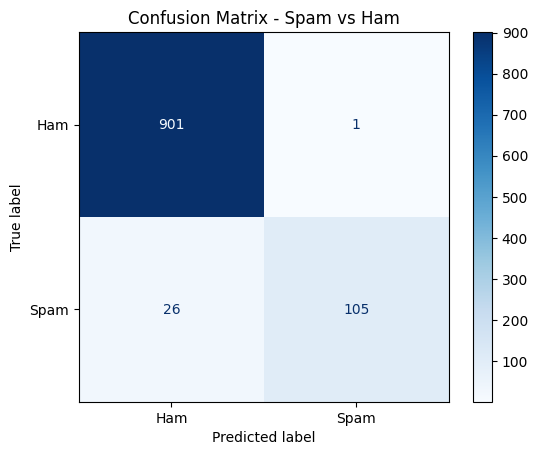

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("=== Confusion Matrix ===")
print(f"True Negative  (Ham benar) : {cm[0][0]}")
print(f"False Positive (Ham salah jadi Spam): {cm[0][1]}")
print(f"False Negative (Spam salah jadi Ham): {cm[1][0]}")
print(f"True Positive  (Spam benar): {cm[1][1]}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Spam vs Ham')
plt.show()